In [1]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model_fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [3]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

In [4]:
from conn_models.quartic import Quartic

In [28]:
#! git pull
import conn_models; reload(conn_models)
from conn_models import common as models_common; reload(models_common)
from conn_models import diag as diag_model; reload(diag_model)
reload(driver)

<module 'driver' from '/home/tootoos/git/glom-io-transform-release/model_fitting/driver.py'>

In [29]:
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model_fitting/fits", models_dir=proj_path + "/model_fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /home/tootoos/git/glom-io-transform-release/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


Loading data from /home/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(1e-08)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 22 initial conditions.


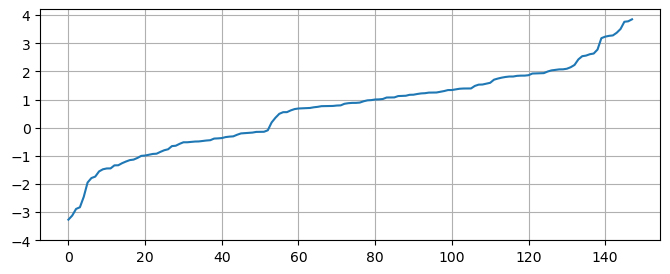

In [30]:
model = trials.model("Diag")
in_file = os.path.join(model.base_dir, "in.27.p")
assert os.path.exists(in_file), f"Input file {in_file} does not exist"
in_params = pickle.load(open(in_file, "rb"))
in_params["data_file"] = in_params["data_file"].replace("/camp/home/tootoos/working/tootoos/git", os.environ["GIT"])
in_params["sampler"]["n_train"] = 10 
in_params["min_args"]["options"]["gtol"]= 1e-8
res, dataset, mdl = driver.run(in_params, return_dataset=True, return_model=True)
plot(sorted(mdl.r)); grid(True); gca().set_yticks(arange(-4, 5, 1))

In [37]:
Q = mdl.compute_quartic_coefs()

All Xs were the same, so mean-of-XY-pairs quartic should be the same as fitting mean Cstar.
Q.[A|B|C|D] = Q_mean.[A|B|C|D]: OK.


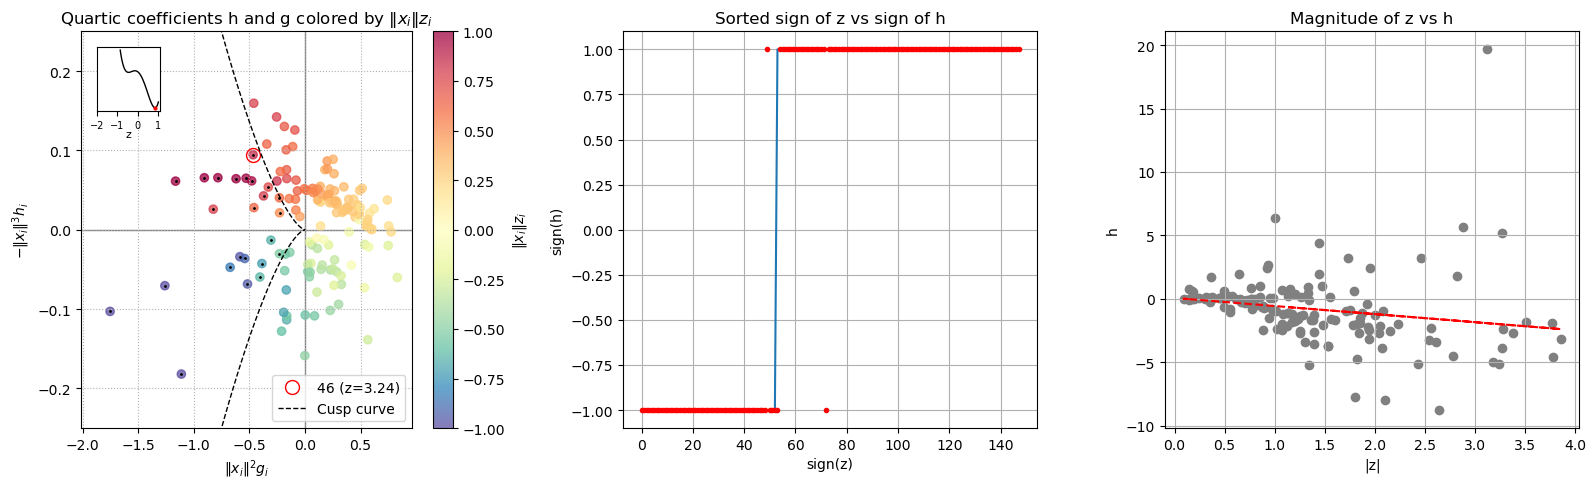

In [40]:
# Plot the p-q plane
figure(figsize=(16,5))
ax1 = subplot(1,3,1)
color_by_dict = {"$z-1$":(Q.z-1, -5, 5, "seismic"),
            "$z$":(Q.z, -4, 4, "Spectral_r"),
            "$\\|x_i\\|z_i$":(Q.z * Xn, -1,1, "Spectral_r"),
            "$k$":(Q.C_, -0.25, 0.25, "coolwarm"),
            "$|z|$":(np.abs(Q.z), 0, 5, "viridis"),
            "$s$": (np.sign(Q.z), -1, 1, "bwr")
}
which_scheme = "$\\|x_i\\|z_i$"
color_by = color_by_dict[which_scheme]
gg =  Q.g_.copy() * Xn**(2*1)
hh = -Q.h_.copy() * Xn**(3*1)
scatter(gg, hh, c = color_by[0], alpha=0.75, cmap=color_by[3], vmin=color_by[1], vmax=color_by[2])
grid(True, linestyle=":")
axhline(0, zorder=-1, lw=1, color="k", alpha=0.5)
axvline(0, zorder=-1, lw=1, color="k", alpha=0.5)
#scatter(Q._p, Q._q, c = Q._c, cmap="rainbow")
ii = np.argsort(Q.z)
in_W = (gg < 0) & (hh**2 < (4/27) * np.abs(gg)**3)
in_V = (gg < 0) & (~in_W)
in_U = (gg > 0)
which_i = where(in_W)[0][10]
plot(gg[which_i], hh[which_i], "ro", label=f"{which_i} (z={Q.z[which_i]:.2f})", markerfacecolor="none", markersize=10)
plot(gg[in_W], hh[in_W], "k.", markersize=2)
xlabel("$\|x_i\|^2 g_i $"); ylabel("$-\|x_i\|^3 h_i$"); title(f"Quartic coefficients h and g colored by {which_scheme}")
colorbar(label=which_scheme)
gvals = np.linspace(min(xlim()), 0, 100)
# Plot the cusp curve: 27 q^2 = 8 (-p)^3
cusp_h = np.sqrt(4/27 * (-gvals)**3)
plot(gvals, cusp_h, "k--", lw=1, label="Cusp curve"); plot(gvals, -cusp_h, "k--", lw=1); legend(loc="lower right")
ax1.set_ylim(-0.25, 0.25)
# Inset: the loss function for the given index
ax_inset = ax1.inset_axes([0.05, 0.8, 0.38/2, 0.32/2])
zvals = np.linspace(Q.z.min(),Q.z.max(),100)
ax_inset.plot(zvals*Xn[which_i], Q.LiFUN(which_i, zvals), lw=1,color="k")
ax_inset.plot(Q.z[which_i]*Xn[which_i], Q.LiFUN(which_i, Q.z[which_i]), "r.", markersize=4)
#ax_inset.axvline(Q.z[which_i] * Xn[which_i], lw=1, color="r")
ax_inset.set_xlabel("z", fontsize=8, labelpad=-1);
ax_inset.set_yticks([]); ax_inset.set_xticks(np.arange(-2,2,1)) 
ax_inset.tick_params(labelsize=7)
# spines_off(ax_inset)
subplot(1,3,2)
plot(np.sign(Q.z[ii])); plot(-np.sign(Q.h_[ii]), "r.")
xlabel("sign(z)"); ylabel("sign(h)"); title("Sorted sign of z vs sign of h"); grid(True)
subplot(1,3,3)
color_by = color_by_dict["$s$"]
xx = np.abs(Q.z)
yy = Q.h_
scatter(xx,yy, color="gray")
slope = (yy - yy.mean()) @ (xx - xx.mean()) / ((xx - xx.mean())**2).sum()
plot(xx, yy.mean() + slope * (xx - xx.mean()), "r--", label=f"Slope = {slope:.2f}")
grid(True)
ylabel("h"); xlabel("|z|"); title("Magnitude of z vs h")
tight_layout()

In [45]:
xn       = norm(mdl.Xs[0],axis=1)
XU       = Q.X/xn[:,None]
mu       = Q.mi_ / (Q.mi_.shape[0] -1)
mu_n     = mu / norm(mu, axis=1)[:, None]
c        = sum(XU * mu, axis=1)
cos_th_i = sum(XU * mu_n, axis=1)
th_i     = arccos(cos_th_i)

# W-responses

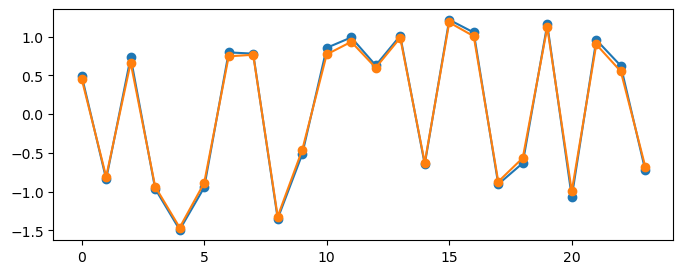

In [55]:
zz = Q.z * xn
ss = sqrt(np.abs(Q.g_)) * xn * sign(-Q.h_)
plot(zz[in_W], "o-")
plot(c[in_W] + ss[in_W], "o-")

# V-responses

# U-responses